# Companion Masterclass: Uncertainty Quantification, Conformal Safety & Risk Modeling

### From Point Predictions to Calibrated Decision Bounds

**Topics:**
1. Limits of Ordinary Least Squares point estimates.
2. Bayesian Linear Regression: exact conjugate Gaussian posterior ($m_N, S_N$).
3. Epistemic vs. Aleatoric uncertainty decomposition.
4. Out-of-Distribution (OOD) detection.
5. Distribution-free Conformal Prediction with non-asymptotic coverage guarantees.
6. Quantile Regression via smoothed IRLS for asymmetric downside risk corridors.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.bayesian import BayesianLinearRegression
from src.conformal import ConformalLinearRegression
from src.quantile import QuantileRegressorScratch
from src.solvers import ClosedFormLinearRegression

---
## 1. Epistemic vs. Aleatoric Uncertainty in Bayesian Regression

For query point $x_*$:
$$p(y_* \mid x_*, X, y) = \mathcal{N}(\mu_*(x_*), \sigma_*^2(x_*))$$
$$\sigma_*^2(x_*) = \underbrace{\frac{1}{\beta}}_{\text{Aleatoric Noise}} + \underbrace{x_*^T S_N x_*}_{\text{Epistemic Uncertainty}}$$

- **Aleatoric Noise ($1/\beta$):** Irreducible variance in observations.
- **Epistemic Uncertainty ($x_*^T S_N x_*$):** Model ignorance. Vanishes near training data clusters, but explodes in out-of-distribution space!

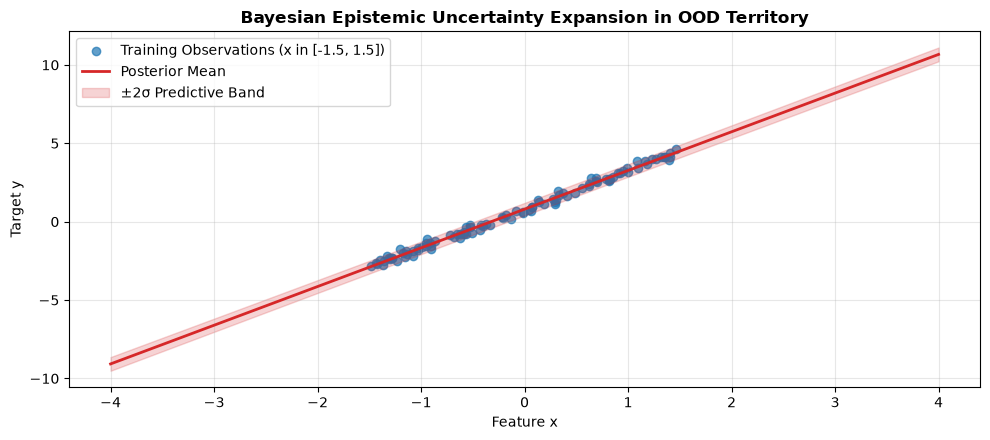

In [2]:
np.random.seed(42)
N = 100
X_train = np.random.uniform(-1.5, 1.5, (N, 1))
y_train = 2.5 * X_train[:, 0] + 0.8 + np.random.normal(0, 0.2, N)

bayes = BayesianLinearRegression(alpha=1.0, beta=25.0)
bayes.fit(X_train, y_train)

# Query grid spanning familiar inliers ([-1.5, 1.5]) and severe OOD extrapolation ([-4, 4])
X_eval = np.linspace(-4, 4, 300).reshape(-1, 1)
y_mean, y_std = bayes.predict(X_eval, return_std=True)

plt.figure(figsize=(10, 4.5))
plt.scatter(X_train, y_train, color="tab:blue", alpha=0.7, label="Training Observations (x in [-1.5, 1.5])")
plt.plot(X_eval, y_mean, color="tab:red", lw=2, label="Posterior Mean")
plt.fill_between(X_eval[:, 0], y_mean - 2*y_std, y_mean + 2*y_std, color="tab:red", alpha=0.2, label="±2σ Predictive Band")
plt.title("Bayesian Epistemic Uncertainty Expansion in OOD Territory", fontweight="bold")
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Conformal Prediction: Distribution-Free Coverage Guarantees

Unlike Bayesian methods, **Split Conformal Prediction** guarantees coverage:
$$P(y_{\text{test}} \in [\hat{\mu}(x) - \hat{q}, \hat{\mu}(x) + \hat{q}]) \ge 1 - \alpha$$
under ANY arbitrary noise distribution without normality assumptions.

In [3]:
# Heavy-tailed Laplace noise
y_laplace = 2.5 * X_train[:, 0] + 0.8 + np.random.laplace(0, 0.3, N)

conformal = ConformalLinearRegression(
    estimator=ClosedFormLinearRegression(method="svd"),
    alpha=0.05,  # 95% nominal confidence
    cal_size=0.25,
    random_state=42
)
conformal.fit(X_train, y_laplace)

# Test evaluation
X_test = np.random.uniform(-1.5, 1.5, (200, 1))
y_test = 2.5 * X_test[:, 0] + 0.8 + np.random.laplace(0, 0.3, 200)

cov = conformal.score_coverage(X_test, y_test)
print("Nominal Confidence Level: 95.00%")
print(f"Empirical Coverage Score: {cov * 100:.2f}% (>= 95.0% guaranteed)")
print(f"Calibrated nonconformity cutoff q_hat: {conformal.q_hat_:.4f}")

Nominal Confidence Level: 95.00%
Empirical Coverage Score: 96.00% (>= 95.0% guaranteed)
Calibrated nonconformity cutoff q_hat: 0.9171


## 3. Quantile Regression: Modeling Conditional Percentiles & Asymmetric Risk

Ordinary least squares models only the mean $\mathbb{E}[y \mid X]$. For financial risk and Value-at-Risk (VaR), we model conditional quantiles:
$$\rho_\tau(u) = u (\tau - \mathbb{I}(u < 0))$$

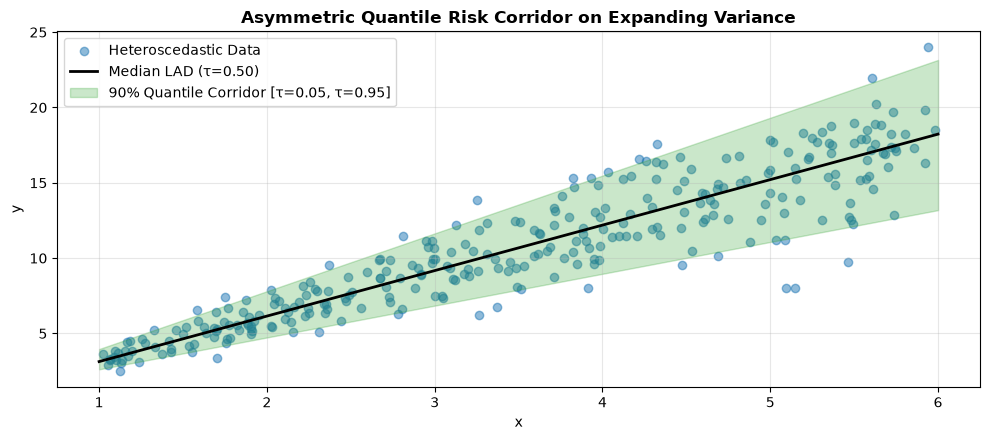

In [4]:
# Heteroscedastic fan data
x_fan = np.random.uniform(1.0, 6.0, 300)
y_fan = 3.0 * x_fan + np.random.normal(0, 0.5 * x_fan, 300)
X_fan = x_fan.reshape(-1, 1)

q_floor = QuantileRegressorScratch(quantile=0.05).fit(X_fan, y_fan)
q_median = QuantileRegressorScratch(quantile=0.50).fit(X_fan, y_fan)
q_ceil = QuantileRegressorScratch(quantile=0.95).fit(X_fan, y_fan)

x_plot = np.linspace(1.0, 6.0, 100).reshape(-1, 1)
pred_floor = q_floor.predict(x_plot)
pred_median = q_median.predict(x_plot)
pred_ceil = q_ceil.predict(x_plot)

plt.figure(figsize=(10, 4.5))
plt.scatter(x_fan, y_fan, color="tab:blue", alpha=0.5, label="Heteroscedastic Data")
plt.plot(x_plot, pred_median, color="black", lw=2, label="Median LAD (τ=0.50)")
plt.fill_between(x_plot[:, 0], pred_floor, pred_ceil, color="tab:green", alpha=0.25, label="90% Quantile Corridor [τ=0.05, τ=0.95]")
plt.title("Asymmetric Quantile Risk Corridor on Expanding Variance", fontweight="bold")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()